In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller

In [33]:
df = pd.read_csv('monthly-sales-of-company-x-jan-6.csv')
df.head()

,Month,Count
0,1965-01,154
1,1965-02,96
2,1965-03,73
3,1965-04,49
4,1965-05,36


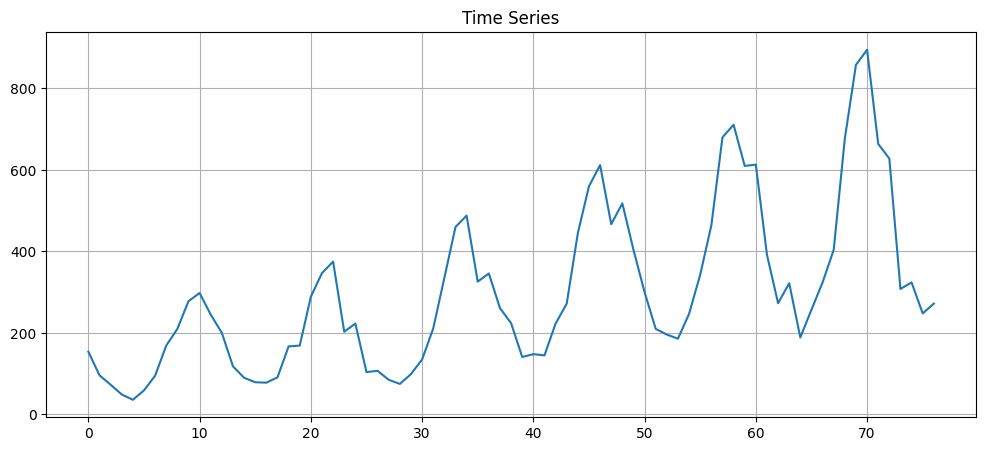

In [34]:
plt.figure(figsize=(12,5))
plt.plot(df['Count'])
plt.title('Time Series')
plt.grid()
plt.show()

In [35]:
result = adfuller(df['Count'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: 0.6547150829524446
p-value: 0.9888894205170052


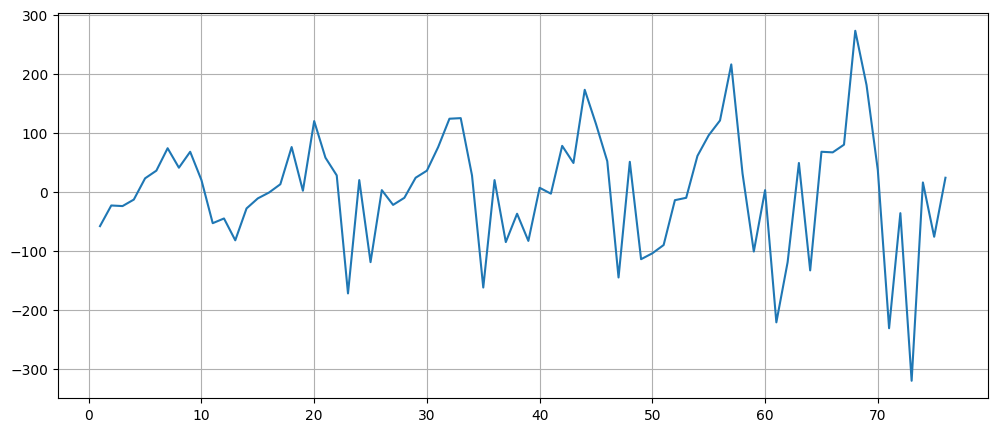

In [36]:
df['Count_diff'] = df['Count'].diff()

df['Count_diff'].plot(figsize=(12,5))
plt.grid()
plt.show()

In [37]:
result = adfuller(df['Count_diff'].dropna())

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -2.587969767062948
p-value: 0.0955092507855888


In [38]:
df['Count_diff2'] = df['Count'].diff().diff()

result = adfuller(df['Count_diff2'].dropna())

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -9.193733965934417
p-value: 2.089629264231227e-15


### Вывод

Для исходного временного ряда значение p-value теста Дики–Фуллера составило 0.9889, что свидетельствует о нестационарности ряда.

После первого дифференцирования значение p-value снизилось до 0.0955, однако осталось выше уровня значимости 0.05, поэтому ряд всё ещё нельзя было считать стационарным.

После выполнения второго дифференцирования значение p-value составило 2.09×10⁻¹⁵, что значительно меньше 0.05. Следовательно, временной ряд стал стационарным после второго дифференцирования.


In [39]:
df = pd.read_csv('monthly-boston-armed-robberies-j.csv')
df.head()

,Month,Count
0,1966-01,41
1,1966-02,39
2,1966-03,50
3,1966-04,40
4,1966-05,43


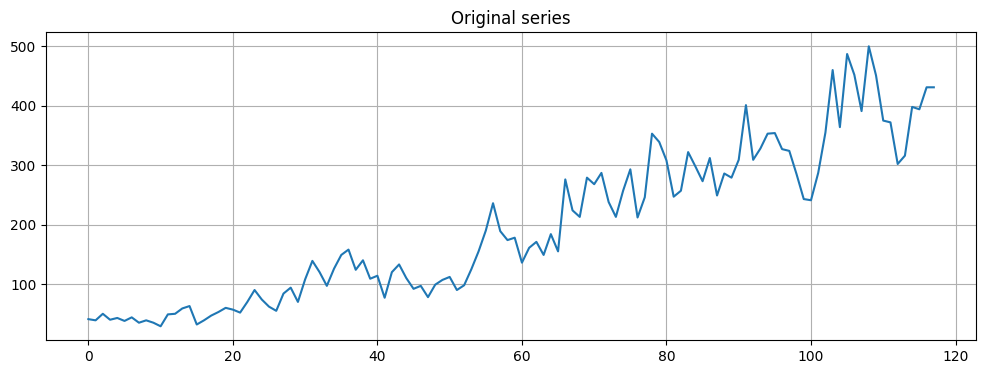

In [40]:
plt.figure(figsize=(12,4))
plt.plot(df.iloc[:,1])
plt.title("Original series")
plt.grid()
plt.show()

In [41]:
result = adfuller(df['Count'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: 1.001102140245781
p-value: 0.994277563805723


In [42]:
df['Count_diff'] = df['Count'].diff()

result = adfuller(df['Count_diff'].dropna())

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -7.42856447506721
p-value: 6.450795412686658e-11


### Вывод

Исходный временной ряд является нестационарным, так как значение p-value теста Дики–Фуллера равно 0.9943, что значительно выше уровня значимости 0.05.

После первого дифференцирования значение p-value снизилось до 6.45×10⁻11, что меньше 0.05. Следовательно, после первого дифференцирования временной ряд становится стационарным.


In [43]:
df = pd.read_csv('international-airline-passengers.csv')
df.head()

,Month,Count
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


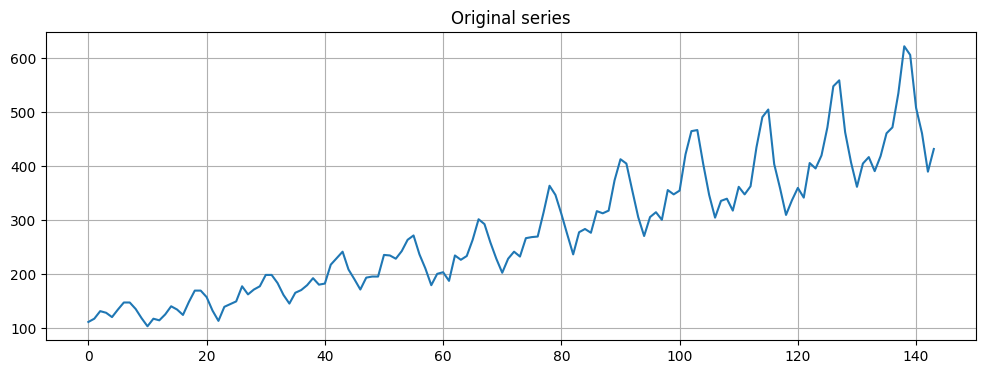

In [44]:
plt.figure(figsize=(12,4))
plt.plot(df.iloc[:,1])
plt.title("Original series")
plt.grid()
plt.show()

In [45]:
result = adfuller(df['Count'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641


In [46]:
df['log'] = np.log(df['Count'])

In [47]:
df['log_seasonal_diff'] = df['log'].diff(12)

In [48]:
result = adfuller(df['log_seasonal_diff'].dropna())

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -2.7095768189885687
p-value: 0.07239567181769489


In [49]:
df['log_seasonal_diff_1'] = df['log'].diff(12).diff()

In [50]:
result = adfuller(df['log_seasonal_diff_1'].dropna())

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -4.4433249418311425
p-value: 0.00024859123113838495


### Вывод

Временной ряд international airline passengers является нестационарным и содержит выраженные тренд и сезонность.

Для приведения ряда к стационарному виду были применены преобразования:

1. Логарифмирование для стабилизации дисперсии.
2. Сезонное дифференцирование с периодом 12 для устранения сезонности.
3. Обычное дифференцирование для удаления остаточного тренда.

После преобразований значение p-value теста Дики–Фуллера составило 0.00025, что меньше 0.05, следовательно, ряд стал стационарным.


In [51]:
df = pd.read_csv('mean-monthly-air-temperature-deg.csv')
df.head()

,Month,Deg
0,1920-01,40.6
1,1920-02,40.8
2,1920-03,44.4
3,1920-04,46.7
4,1920-05,54.1


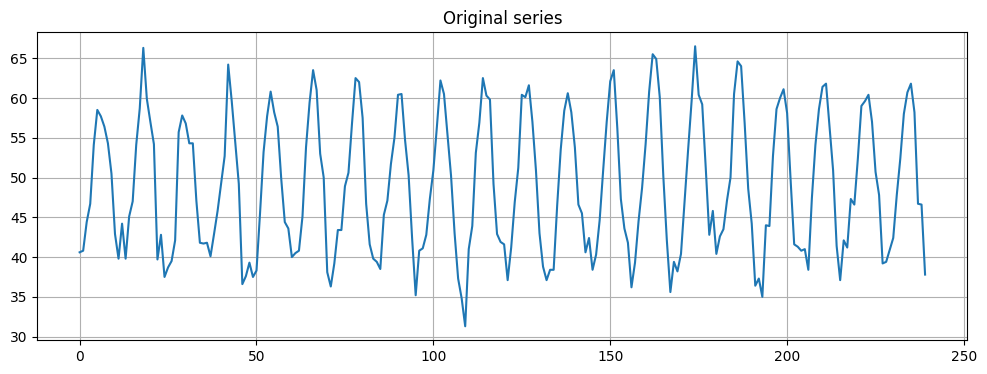

In [52]:
plt.figure(figsize=(12,4))
plt.plot(df.iloc[:,1])
plt.title("Original series")
plt.grid()
plt.show()

In [53]:
result = adfuller(df['Deg'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -3.2554924030863366
p-value: 0.016989030222608604


### Вывод

Для временного ряда mean monthly air temperature значение p-value теста Дики–Фуллера составило 0.017, что меньше 0.05. Следовательно, нулевая гипотеза о наличии единичного корня отвергается, и ряд можно считать стационарным без дополнительных преобразований.


In [54]:
df = pd.read_csv('weekly-closings-of-the-dowjones-.csv')
df.head()

,Week,Close
0,1971-W27,890.19
1,1971-W28,901.80
2,1971-W29,888.51
3,1971-W30,887.78
4,1971-W31,858.43


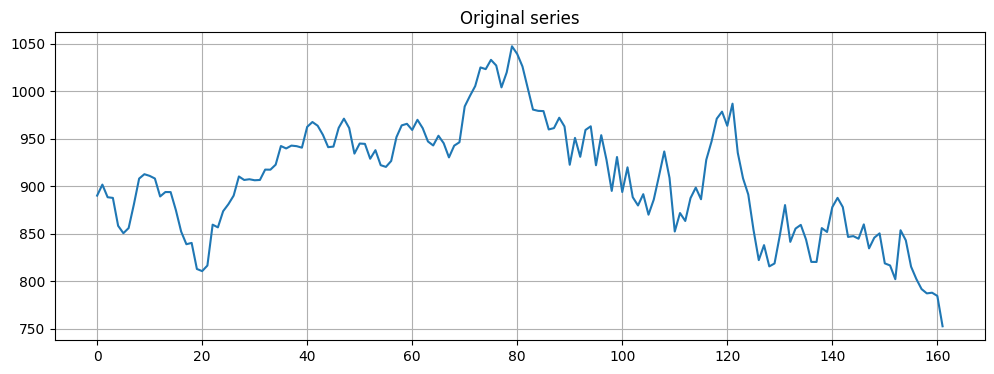

In [55]:
plt.figure(figsize=(12,4))
plt.plot(df.iloc[:,1])
plt.title("Original series")
plt.grid()
plt.show()

In [56]:
result = adfuller(df['Close'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -1.3146254984911683
p-value: 0.6224548515589733


In [57]:
df['diff'] = df['Close'].diff()

from statsmodels.tsa.stattools import adfuller

result = adfuller(df['diff'].dropna())

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -13.025207881234948
p-value: 2.4075864037417794e-24


### Вывод

Исходный временной ряд weekly closings of the Dow Jones является нестационарным, так как значение p-value теста Дики–Фуллера равно 0.6225, что значительно превышает уровень значимости 0.05.

После применения первого дифференцирования значение p-value снизилось до 2.41×10⁻24, что меньше 0.05. Следовательно, после преобразования ряд становится стационарным.


In [58]:
df = pd.read_csv('daily-total-female-births-in-cal.csv')
df.head()

,Date,Count
0,1959-01-01,35
1,1959-01-02,32
2,1959-01-03,30
3,1959-01-04,31
4,1959-01-05,44


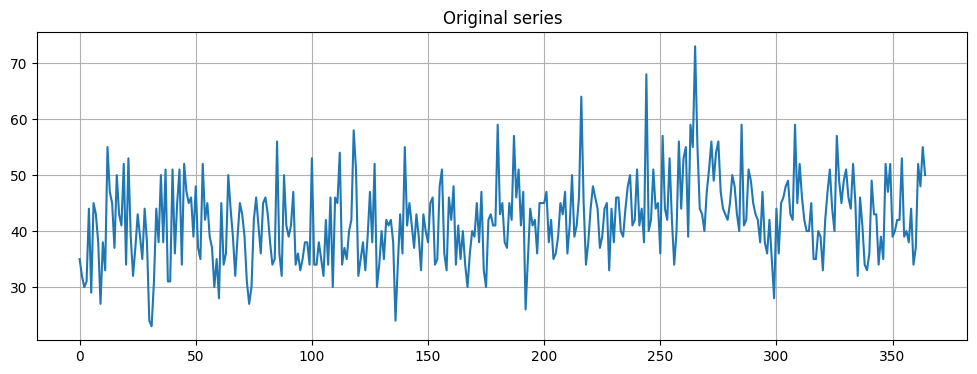

In [59]:
plt.figure(figsize=(12,4))
plt.plot(df.iloc[:,1])
plt.title("Original series")
plt.grid()
plt.show()

In [60]:
result = adfuller(df['Count'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -4.808291253559765
p-value: 5.2434129901498554e-05


### Вывод

Временной ряд daily total female births in California является стационарным, так как значение p-value теста Дики–Фуллера составляет 5.24×10⁻5, что меньше уровня значимости 0.05.

Следовательно, дополнительные преобразования (дифференцирование или логарифмирование) не требуются.
